# Semana 1: Fundamentos de la valoración financiera · Práctica

**Tópicos de Finanzas Avanzadas (ECON-421, UPAO 2026-20)** · CFA · Equity: *Equity Valuation: Applications and Processes*

**Hoy:**
1. Verificar que tu entorno funciona (Python + VS Code + venv + Git).
2. Programar las tres funciones que usaremos todo el semestre: `vp()`, `vpn()`, `tir()`.
3. Descargar tus primeros **datos reales** (Yahoo Finance y API BCRPData).
4. Publicar tu trabajo con `git add`  `git commit`  `git push`.

> Regla del curso: **nada de copiar datos a mano**, todo entra por API para que el notebook sea reproducible.

## 0. Diagnóstico del entorno

Ejecuta la celda siguiente (`Shift+Enter`). Si todo está bien instalado, imprime las versiones sin errores.
Si algo falla, revisa la [guía de instalación](../00_setup/guia_instalacion.md).

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("Python      :", sys.version.split()[0])
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("matplotlib  :", matplotlib.__version__)
print("\n Entorno operativo")

Python      : 3.10.11
numpy       : 2.1.3
pandas      : 2.2.3
matplotlib  : 3.9.2

 Entorno operativo


## 1. El valor del dinero en el tiempo

Todo activo financiero es una promesa de flujos futuros. Su valor **hoy** es:

$$VP = \sum_{t=1}^{n} \frac{CF_t}{(1+r)^t} \qquad\qquad VPN = -CF_0 + VP$$

donde $r$ es la tasa que **exigimos** por esperar y por arriesgar. Programemos esto una sola vez y para siempre:

In [2]:
def vp(flujos, r):
    """Valor presente de una lista de flujos CF_1..CF_n a la tasa r."""
    return sum(cf / (1 + r) ** t for t, cf in enumerate(flujos, start=1))


def vpn(cf0, flujos, r):
    """VPN = -inversión inicial + valor presente de los flujos."""
    return -cf0 + vp(flujos, r)


# El ejemplo de la clase: invertir 100, recibir 30, 40 y 60, r = 10%
resultado = vpn(100, [30, 40, 60], 0.10)
print(f"VPN = {resultado:.2f}")   # debe dar 5.41  se acepta el proyecto

VPN = 5.41


In [ ]:
print(VPN)

### La TIR: la tasa que hace VPN = 0

La TIR no tiene fórmula cerrada: se encuentra **numéricamente**. Usamos `numpy.roots` sobre el polinomio del VPN:

In [3]:
def tir(cf0, flujos):
    """Tasa interna de retorno: la r que hace VPN = 0 (raíz real positiva)."""
    # Polinomio en x = 1/(1+r):  -cf0 + CF1·x + CF2·x² + ... = 0
    coefs = list(reversed(flujos)) + [-cf0]
    raices = np.roots(coefs)
    reales = raices[np.isreal(raices)].real
    candidatas = [1 / x - 1 for x in reales if x > 0]
    return min([r for r in candidatas if r > -1], key=abs)


r_star = tir(100, [30, 40, 60])
print(f"TIR = {r_star:.2%}")                        # ≈ 12.7%
print(f"Comprobación: VPN a la TIR = {vpn(100, [30, 40, 60], r_star):.6f}")

TIR = 12.71%
Comprobación: VPN a la TIR = 0.000000


### El perfil del VPN

¿Cómo cambia el veredicto con la tasa exigida? Grafiquemos VPN vs. $r$, la curva cruza cero exactamente en la TIR:

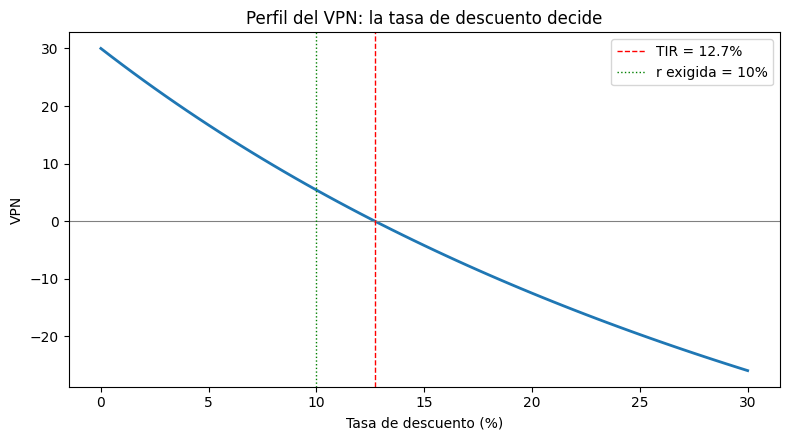

In [4]:
tasas = np.linspace(0.0, 0.30, 61)
perfil = [vpn(100, [30, 40, 60], r) for r in tasas]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(tasas * 100, perfil, lw=2)
ax.axhline(0, color="gray", lw=0.8)
ax.axvline(r_star * 100, color="red", ls="--", lw=1, label=f"TIR = {r_star:.1%}")
ax.axvline(10, color="green", ls=":", lw=1, label="r exigida = 10%")
ax.set_xlabel("Tasa de descuento (%)")
ax.set_ylabel("VPN")
ax.set_title("Perfil del VPN: la tasa de descuento decide")
ax.legend()
plt.tight_layout()
plt.show()

**Lectura:** a la izquierda de la TIR el proyecto crea valor; a la derecha lo destruye. Por eso la semana 2 está dedicada
íntegramente a estimar bien la tasa de descuento (CAPM y WACC).

## 2. Primeros datos reales

### 2.1 Yahoo Finance: una acción peruana

Descargamos el precio de **Credicorp (BAP)**, el mayor holding financiero del Perú, listado en NYSE:

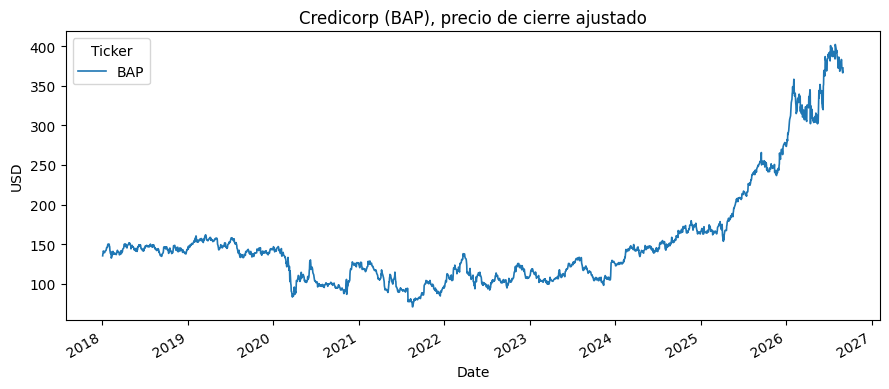

Ticker             BAP
Date                  
2026-08-26  382.549988
2026-08-27  373.200012
2026-08-31  366.380005
2026-09-01  372.519989
2026-09-02         NaN


In [7]:
import yfinance as yf

bap = yf.download("BAP", start="2018-01-01", auto_adjust=True, progress=False)["Close"]

fig, ax = plt.subplots(figsize=(9, 4))
bap.plot(ax=ax, lw=1.2)
ax.set_title("Credicorp (BAP), precio de cierre ajustado")
ax.set_ylabel("USD")
plt.tight_layout()
plt.show()

print(bap.tail())

### 2.2 API BCRPData: el tipo de cambio

El BCRP publica miles de series por API. Usamos la mini-librería del curso (`utils/bcrp.py`):

>  Verifica el código de la serie en el [portal BCRPData](https://estadisticas.bcrp.gob.pe/estadisticas/series/), los códigos pueden cambiar.

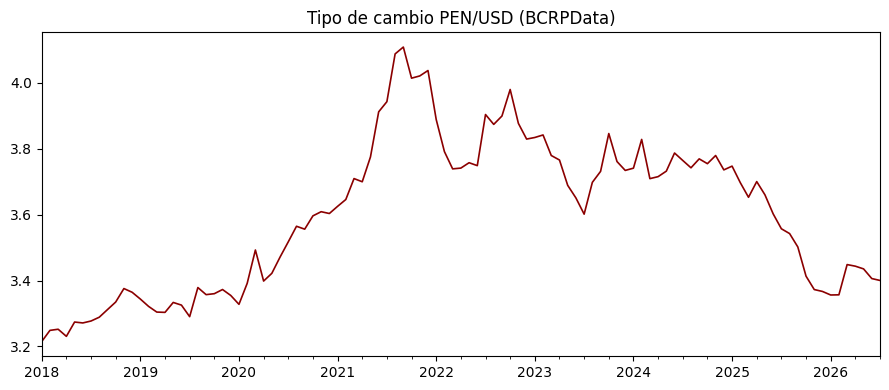

In [8]:
import sys; sys.path.append("..")   # para importar utils/ desde la carpeta de la semana
from utils import bcrp

tc = bcrp.get_series("PN01207PM", "2018-1", "2026-8")   # tipo de cambio interbancario promedio, mensual

fig, ax = plt.subplots(figsize=(9, 4))
tc.plot(ax=ax, lw=1.2, color="darkred")
ax.set_title("Tipo de cambio PEN/USD (BCRPData)")
plt.tight_layout()
plt.show()

## 3. Precio vs. valor: la pregunta del semestre

El precio de BAP lo acabas de ver. Su **valor intrínseco** no se descarga de ninguna API: hay que *estimarlo*
proyectando flujos y descontándolos, exactamente lo que aprenderemos en las semanas 2-5.

$$\underbrace{V_E - P}_{\text{mispricing percibido}} = \underbrace{(V-P)}_{\text{mispricing verdadero}} + \underbrace{(V_E-V)}_{\text{error de estimación}}$$

**Discusión (celda de texto):** ¿qué información necesitarías para estimar el valor intrínseco de BAP?
Anota al menos 4 elementos: los iremos consiguiendo uno por uno en las próximas semanas.

## 4. Tu primera entrega

En la terminal de VS Code (con tu fork clonado):

```bash
git add 01_fundamentos_valor/clase01_practica.ipynb
git commit -m "Semana 1: practica completada"
git push
```

Verifica en tu GitHub que el commit aparezca. **Eso es una entrega en este curso.**